Overview

The project analyses student attitudes towards AI across three categories: ethical concerns, usage habits, and emotional sentiment. Due to the increased growth of AI in mundane everyday tasks, our project aims to understand how students perceive and interact with AI.
The data in the analysis was collected from the CS105 Survey data package. The data surveyed students about AI usage behaviors, reliability perceptions, ethical concerns regarding AI-generated content, and personal demographics including gender and class standing. 


Hypothesis 1: 

Null Hypothesis: There is no correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues.

Alternate Hypothesis: There is a correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues

Data Cleaning

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

for col in [ethics_col] + political_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ethics concern: fill missing with column median
ethics_median = df[ethics_col].median()
df[ethics_col] = df[ethics_col].fillna(ethics_median)

# Political issues: fill missing with person's row average, fall back to column median if all blank
political_medians = df[political_cols].median()

for idx, row in df[political_cols].iterrows():
    answered = row.dropna()
    if len(answered) == 0:
        df.loc[idx, political_cols] = row.fillna(political_medians)
    elif row.isna().any():
        df.loc[idx, political_cols] = row.fillna(answered.mean())

# Round to integers
df[ethics_col] = df[ethics_col].round().astype(int)
for col in political_cols:
    df[col] = df[col].round().astype(int)

df.to_csv('data_cleaned_ethics_political.csv', index=False)

Cleaning: 
About 30% of the responses to the Political Issues were initally blank since the question was added late to the survey. For respondants that were missing values for each politics section we filled in the median. For respondants that left some of the responses blank, we filled in the missing response with their average across political questions.

About 30% of responses to the Ethics of AI question were initially blank since the question was added late to the survey. We cleaned this by filling in the the missing values with median 4. This is since there are no other similar questions to average for the response.

Visualization 1: Bar Chart

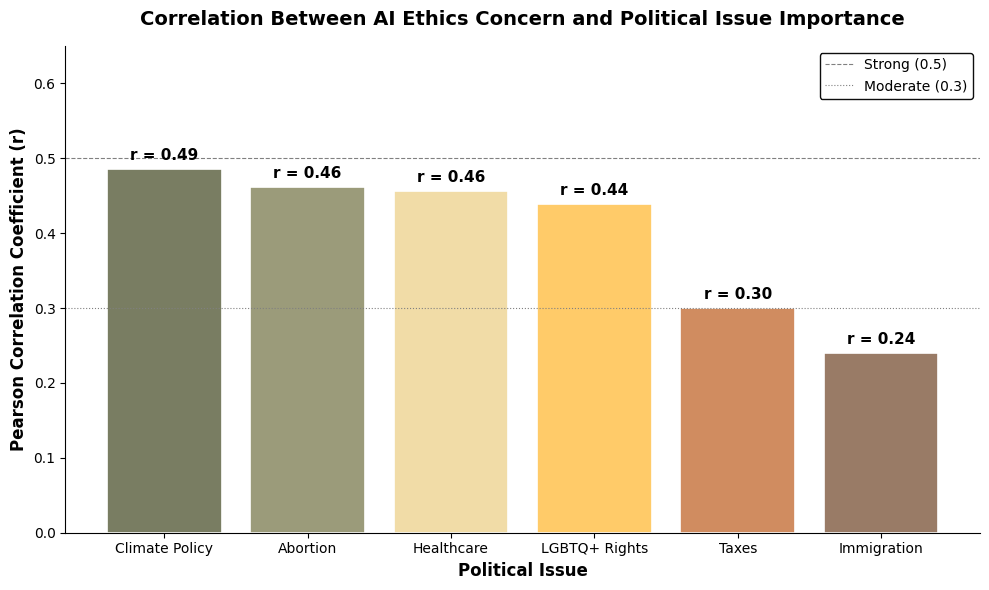

In [3]:
# I used the lab5-6 guide to make the bar graph, as well as claude
# for cleaning the data
import matplotlib.pyplot as plt

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

political_short = ['Immigration', 'Abortion', 'LGBTQ+ Rights', 'Taxes', 'Healthcare', 'Climate Policy']

corr_values = {label: df[ethics_col].corr(df[col]) for col, label in zip(political_cols, political_short)}
corr_series = pd.Series(corr_values).sort_values(ascending=False)

colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(corr_series.index, corr_series.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, corr_series.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008, f'r = {val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Strong (0.5)')
ax.axhline(y=0.3, color='gray', linestyle=':', linewidth=0.8, label='Moderate (0.3)')

ax.set_ylim(0, 0.65)
ax.set_xlabel('Political Issue', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax.set_title('Correlation Between AI Ethics Concern and Political Issue Importance', fontsize=14, fontweight='bold', pad=15)
legend = ax.legend(fontsize=10, loc='upper right', framealpha=0.95, edgecolor='black', fancybox=True)
for text in legend.get_texts():
    text.set_color('black')
legend.get_frame().set_facecolor('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Visualization Justification: The x axis is our political issue variable, and the y axis is our Pearson correlation coefficient in relation to AI ethics concern. The coefficient ranges from -1 to 1, which indicates the linear relationship of our variables.

Analysis and Conclusion: The bar graph shows that students who hold a higher importance on certain political issues tend to be moderately more concerned about AI ethics on socail media. This relationship is consistent across all political issues, but is most prominant with climate policy. This suggests a connection between environmental concern and AI ethics concern.

Visualization 2: Box Plot Matrix

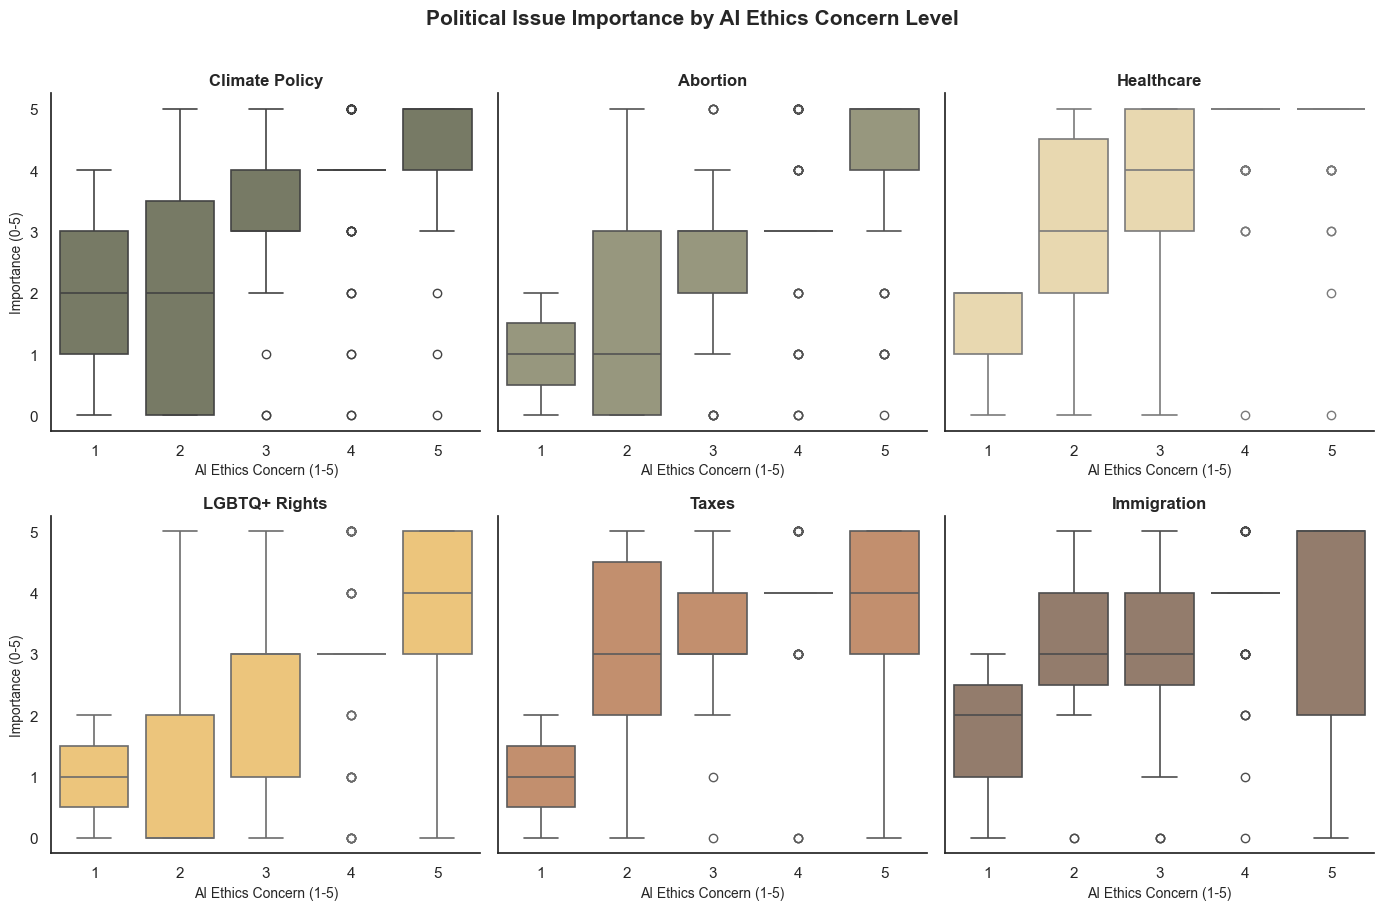

In [9]:
# I used the lab5-6 guide to make the box plot matrix as well as claude
# for cleaning the data
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
]

political_short = ['Climate Policy', 'Abortion', 'Healthcare', 'LGBTQ+ Rights', 'Taxes', 'Immigration']
colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(political_cols, political_short, colors)):
    sns.boxplot(data=df, x=ethics_col, y=col, ax=axes[i], color=color, linewidth=1.2)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('AI Ethics Concern (1-5)', fontsize=10)
    axes[i].set_ylabel('Importance (0-5)' if i % 3 == 0 else '', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Political Issue Importance by AI Ethics Concern Level', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Box Pot Matrix: Each box plot shows the distribution of a political topic's importance ratings across each level of AI ethics concern, with one cell per political issue. Unlike the bar graph, this plot summarizes the statistics of each individual group (median, IQR, outliers). This better depicts the center of spread across ethics concern levels at a glance. Gathering the political issues into a matrix allows for the comparison of trends of the median.

Analysis: For all 6 political issues, the median importance score of AI ethics concern increases. This confirms the positive correlation shown in the bar chart. Health care has the strongest upward trend, closely followed by climate policy. Immigration and taxes have a more moderate upward trend.

Visualization 3: Ridge Graph

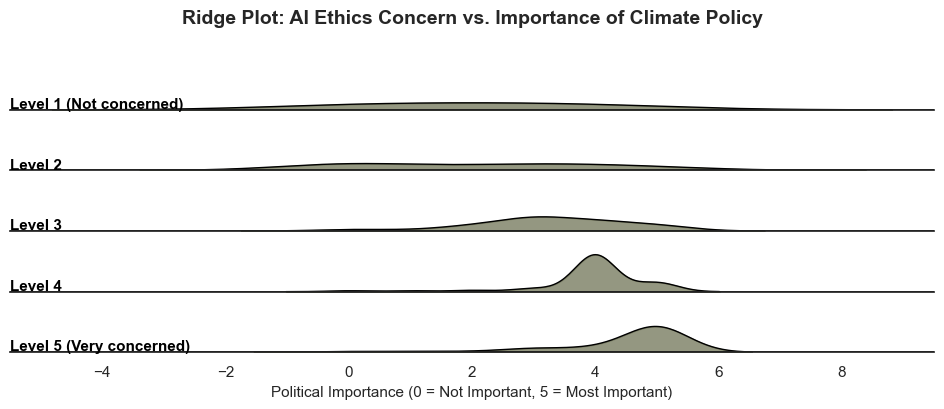

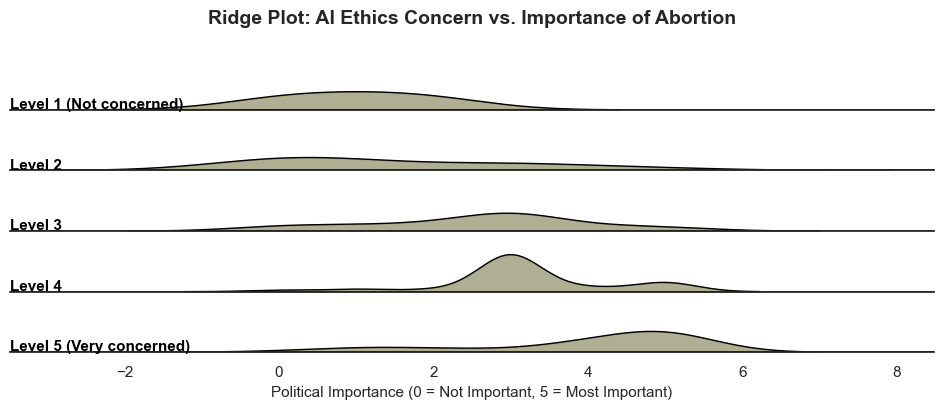

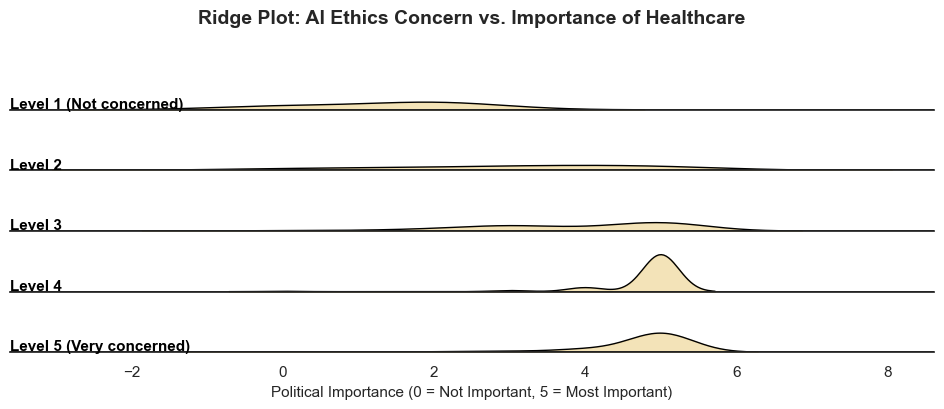

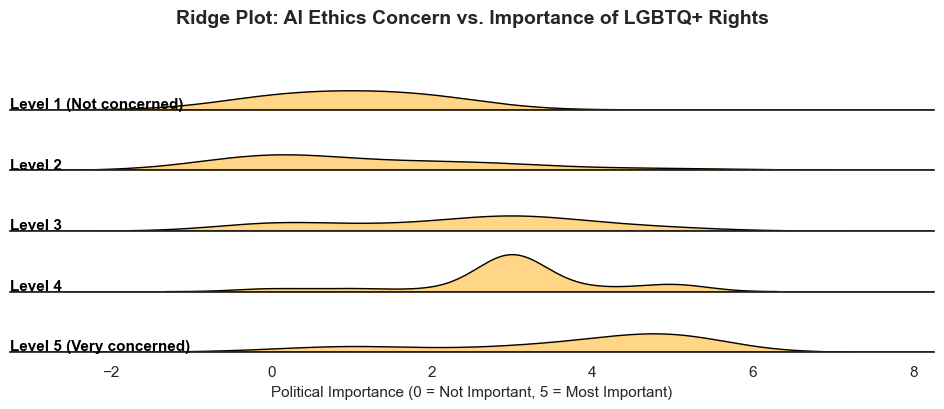

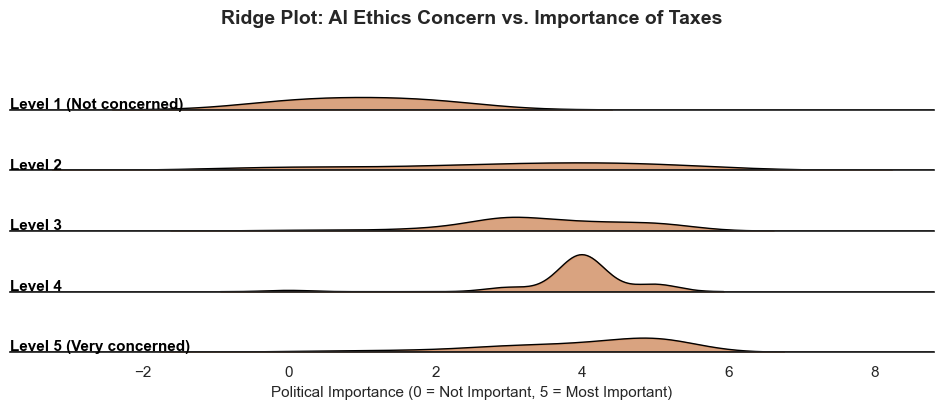

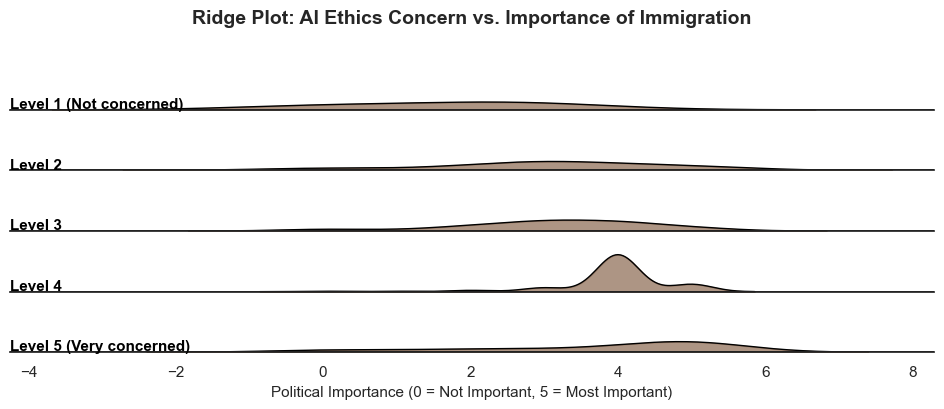

In [12]:
# I used the lab5-6 guide to make the ridge graph, as well as claude
# for cleaning the data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

political_cols = {
    'Climate Policy': 'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
    'Abortion':      'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Healthcare':    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'LGBTQ+ Rights': 'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Taxes':         'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Immigration':   'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
}

issue_colors = {
    'Climate Policy': '#797D62',
    'Abortion':       '#9B9B7A',
    'Healthcare':     '#F1DCA7',
    'LGBTQ+ Rights':  '#FFCB69',
    'Taxes':          '#D08C60',
    'Immigration':    '#997B66',
}

ethics_labels = {
    1: 'Level 1 (Not concerned)',
    2: 'Level 2',
    3: 'Level 3',
    4: 'Level 4',
    5: 'Level 5 (Very concerned)',
}

ethics_order = list(ethics_labels.values())

rows = []
for label, col in political_cols.items():
    sub = df[[ethics_col, col]].dropna().copy()
    sub.columns = ['Ethics Concern', 'Political Importance']
    sub['Political Issue'] = label
    sub['Ethics Level'] = sub['Ethics Concern'].map(ethics_labels)
    rows.append(sub)

long_df = pd.concat(rows, ignore_index=True)
issues = ['Climate Policy', 'Abortion', 'Healthcare', 'LGBTQ+ Rights', 'Taxes', 'Immigration']

for issue in issues:
    issue_df = long_df[long_df['Political Issue'] == issue].copy()

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    g = sns.FacetGrid(
        issue_df,
        row="Ethics Level",
        hue="Ethics Level",
        aspect=12,
        height=0.8,
        palette=[issue_colors[issue]] * len(ethics_order),
        row_order=ethics_order,
        hue_order=ethics_order,
    )

    g.map(sns.kdeplot, "Political Importance", fill=True, alpha=0.8)
    g.map(sns.kdeplot, "Political Importance", color="black", linewidth=1)
    g.map(plt.axhline, y=0, linewidth=2, color="black")

    def label_ridge(x, color, label):
        ax = plt.gca()
        ax.text(0, 0.15, label, fontweight="bold", color="black",
                ha="left", va="center", transform=ax.transAxes, fontsize=11)

    g.map(label_ridge, "Political Importance")

    g.fig.suptitle(
        f"Ridge Plot: AI Ethics Concern vs. Importance of {issue}",
        fontsize=14, fontweight='bold', y=1.02
    )
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set_xlabels("Political Importance (0 = Not Important, 5 = Most Important)", fontsize=11)
    g.despine(left=True)

    plt.tight_layout()
    plt.show()

Ridge plot: The ridge plots show the full distribution of political importance ratings for each level of AI ethics concern (rated 1-5), separetly for each political issue. Instead of displaying a summary stastistic, we chose the ridge plot as it is able to show the distribution shifts as ethics concern increases, such as, whether distributions broaden, sharpen, or shift in location. Each political importance is demonstrated through a ridge based on the level of importance displayed through levels of concern regarding AI.

Analysis: Respondents at lower ethics concern levels (Level 1, Level 2) typically have distributions centered at low importance ratings across all six political issues, whereas respondents at higher ethics concern levels (Level 4, Level 5) exhibit more peaked distributions centered at higher importance values for politics. (add 1-2 sentences on trends). This is supported by the bar chart's showcase that greater AI ethics concern is linked to increased political activity demonstrated through the ridge plot.


Chi Square

In [6]:
from scipy.stats import chi2_contingency

df = pd.read_csv('data_cleaned_ethics_political.csv')

var1_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

var1 = pd.to_numeric(df[var1_col], errors='coerce')
political_df = df[political_cols].apply(pd.to_numeric, errors='coerce')
var2 = political_df.mean(axis=1)

# Bin var1 (1-5 scale, heavily skewed high) into 2 groups
# Low/Medium (1-3): 61 respondents | High (4-5): 165 respondents
var1_binned = pd.cut(var1, bins=[0.9, 3.5, 5], labels=['Low/Medium (1-3)', 'High (4-5)'])

# Bin var2 (average political importance, 0-5) into 3 groups
var2_binned = pd.cut(var2, bins=[-0.1, 2.5, 3.5, 5.1], labels=['Low (0-2.5)', 'Medium (2.5-3.5)', 'High (3.5-5)'])

contingency_table = pd.crosstab(var1_binned, var2_binned)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

Chi-Square Statistic: 80.97
P-value: 0.0000
Degrees of Freedom: 2


Chi-Square Statistic: 80.97
P-value: 0.0000

Result: Reject the Null Hypothesis.
Conclusion: There IS a statistically significant correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues.